## Importación y configuración de librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore') # Evita ensuciar el notebook con mensajes de advertencia.
pd.set_option('display.max_columns', None) # Muestra todas las columnas al mostrar un dataframe.
pd.set_option('display.float_format', '{:.2f}'.format) # Muestra los números decimales con dos dígitos.

print('Librerías cargadas correctamente.')
print(f'pandas {pd.__version__} | numpy {np.__version__}')

Librerías cargadas correctamente.
pandas 2.3.3 | numpy 2.3.4


## Carga del dataset

In [3]:
ruta = './data/Gaming_Academic_Performance.csv'
df_raw = pd.read_csv(ruta) 
print('Dataset cargado correctamente.')
print(f'Número de filas: {df_raw.shape[0]} | Número de columnas: {df_raw.shape[1]}')
df_raw.head()

Dataset cargado correctamente.
Número de filas: 8000 | Número de columnas: 14


,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.46
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.23
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.56
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.67
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.71


In [4]:
# Creamos una copia para mantener el dataset original intacto.
df = df_raw.copy()

## Auditoría Inicial

Documentación y entendimiento del dataset.

In [5]:
# Mostramos la inforamción general del dataframe.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        8000 non-null   int64  
 1   age               8000 non-null   int64  
 2   gender            8000 non-null   object 
 3   gaming_hours      8000 non-null   float64
 4   study_hours       8000 non-null   float64
 5   sleep_hours       8000 non-null   float64
 6   attendance        8000 non-null   float64
 7   gaming_genre      8000 non-null   object 
 8   social_activity   8000 non-null   float64
 9   device_usage      8000 non-null   float64
 10  reaction_time_ms  8000 non-null   float64
 11  addiction_score   8000 non-null   float64
 12  stress_level      8000 non-null   object 
 13  grades            8000 non-null   float64
dtypes: float64(9), int64(2), object(3)
memory usage: 875.1+ KB


No parece que haya valores nulos. Hay 3 variables categóricas que es posible que haya que corregir o clasificar.

In [6]:
# Muestra estadísticas descriptivas para todas las columnas.
df.describe(include='all')

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
count,8000.00,8000.00,8000,8000.00,8000.00,8000.00,8000.00,8000,8000.00,8000.00,8000.00,8000.00,8000,8000.00
unique,NaN,NaN,3,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,Male,NaN,NaN,NaN,NaN,FPS,NaN,NaN,NaN,NaN,Medium,NaN
freq,NaN,NaN,3904,NaN,NaN,NaN,NaN,3187,NaN,NaN,NaN,NaN,4247,NaN
mean,4000.50,19.98,NaN,4.09,5.46,6.49,79.89,NaN,2.51,7.59,271.11,9.91,NaN,66.18
std,2309.55,2.59,NaN,2.31,2.58,1.44,11.58,NaN,1.44,2.71,29.44,5.04,NaN,22.42
min,1.00,16.00,NaN,0.00,1.00,4.00,60.00,NaN,0.00,1.10,183.26,-4.51,NaN,0.00
25%,2000.75,18.00,NaN,2.13,3.24,5.24,69.78,NaN,1.29,5.56,247.16,5.92,NaN,49.88
50%,4000.50,20.00,NaN,4.13,5.46,6.50,79.69,NaN,2.50,7.61,270.48,10.00,NaN,67.07
75%,6000.25,22.00,NaN,6.06,7.66,7.73,90.10,NaN,3.76,9.60,294.69,13.86,NaN,83.99


Encontramos algunos valores interesantes como un valor negativo en addition_score, o valores muy altos en grades. Se corregirán más adelante.

In [7]:
# Mostramos el número de valores nulos con su porcentaje.
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
info_nulos = pd.DataFrame({'Nulos': nulos, '%': nulos_pct})

# Mostrmaos si existen, c.c. mostrar mensaje de ausencia de valores nulos.
if info_nulos['Nulos'].sum() > 0:
    print('Valores nulos encontrados:')
    print(info_nulos[info_nulos['Nulos'] > 0])
else:
    print('No se encontraron valores nulos en el dataset.')

No se encontraron valores nulos en el dataset.


Nos encontramos en ausencia de valores nulos.

In [8]:
# Mostramos el número de valores duplicados.
n_duplicados = df.duplicated().sum()
n_ids_duplicados = df['student_id'].duplicated().sum()

print(f'Filas completamente duplicadas: {n_duplicados}')
print(f'IDs de estudiantes duplicados: {n_ids_duplicados}')

Filas completamente duplicadas: 0
IDs de estudiantes duplicados: 0


Comprobamos que no existen registros completamente duplicados ni que hay mismos ID de estudiantes.

In [ ]:
# Distribución de variables categóricas.
col_cat = ['gender','gaming_genre','stress_level']

for col in col_cat:
    print(f'\n-- {col} --')
    conteo = df[col].value_counts(dropna=False) # Muestra los valores nulos también.
    pct = (conteo /len(df) * 100).round(1)
    print(pd.DataFrame({'Conteo': conteo, '%': pct}))


-- gender --
        Conteo     %
gender              
Male      3904 48.80
Female    3803 47.50
Other      293  3.70

-- gaming_genre --
              Conteo     %
gaming_genre              
FPS             3187 39.80
RPG             2408 30.10
Casual          2405 30.10

-- stress_level --
              Conteo     %
stress_level              
Medium          4247 53.10
Low             2743 34.30
High            1010 12.60


Las clases están más o menos balanceadas, y no parece que haya errores de escritura.

In [ ]:
# Rango lógico de variables numéricas.
rangos_esperados = {
    'age': (16,24),
    'gaming_hours': (0,8),
    'study_hours': (0,10),
    'sleep_hours': (0,12),
    'attendance': (0,100),
    'social_activity': (0,5),
    'device_usage': (0,24),
    'reaction_time_ms': (100,600),
    'addiction_score': (0,30),
    'grades': (0,100)
}

info_filas = []

for col, (lo, hi) in rangos_esperados.items():
    fuera_rango = ((df[col] < lo) | (df[col] > hi)).sum()
    info_filas.append({
        'columna' : col,
        'min_esperado' : lo,
        'max_esperado' : hi,
        'min_observado' : df[col].min(),
        'max_observado' : df[col].max(),
        'fuera_rango' : fuera_rango,
        'estado': 'OK' if fuera_rango == 0 else 'Revisar'
    })

pd.DataFrame(info_filas)

,columna,min_esperado,max_esperado,min_observado,max_observado,fuera_rango,estado
0,age,16,24,16.00,24.00,0,OK
1,gaming_hours,0,8,0.00,8.00,0,OK
2,study_hours,0,10,1.00,10.00,0,OK
3,sleep_hours,0,12,4.00,9.00,0,OK
4,attendance,0,100,60.00,100.00,0,OK
5,social_activity,0,5,0.00,5.00,0,OK
6,device_usage,0,24,1.10,13.95,0,OK
7,reaction_time_ms,100,600,183.26,347.87,0,OK
8,addiction_score,0,30,-4.51,23.16,107,Revisar
9,grades,0,100,0.00,118.63,134,Revisar


Las variables addiction score y grades contienen valores fuera del rango esperado. Se revisarán y corregirán más tarde.

## Análisis en detalle de anomalías

Investigamos algunas anomalías detectadas anteriormente.

In [13]:
# Puntuaciones superiores a 100 en grades.
mask_grades = df['grades'] > 100

print(f'Registros afectados: {mask_grades.sum()}')
print(f'Rango observado: {df["grades"].min():.2f} - {df["grades"].max():.2f}')
print()
print(f'Estadísticas de los valores problemáticos:')
df.loc[mask_grades, 'grades'].describe()

Registros afectados: 134
Rango observado: 0.00 - 118.63

Estadísticas de los valores problemáticos:


count   134.00
mean    105.99
std       3.14
min     100.05
25%     104.20
50%     106.52
75%     108.08
max     118.63
Name: grades, dtype: float64

Vemos que hay 134 registros afectados, y se alejan como máximo en 18 puntos, lo que parece un error de captura.

Revisamos el contexto del estudiante con las puntuaciones anómalas.

In [14]:
print(f'Muestra de registros con grades > 100:')
df.loc[mask_grades, ['student_id', 'age', 'gaming_hours', 'study_hours', 'attendance', 'stress_level', 'grades']].head(10)

Muestra de registros con grades > 100:


,student_id,age,gaming_hours,study_hours,attendance,stress_level,grades
22,23,24,6.17,9.74,63.69,Low,100.82
90,91,16,3.47,9.41,69.30,Medium,108.77
127,128,22,0.14,8.14,84.44,Medium,109.08
138,139,24,0.27,9.71,82.59,High,105.99
205,206,18,1.87,6.90,76.28,Medium,108.90
222,223,21,4.20,9.72,95.11,Medium,108.06
275,276,21,2.01,9.89,86.96,Medium,106.28
281,282,20,6.47,8.54,97.60,Low,104.48
304,305,21,1.21,8.69,69.92,Medium,107.25
408,409,17,0.05,5.26,92.73,Medium,101.01


Parece que las demás variables tienen una correlación con sentido, lo que explica más que lo único que falla es la introducción de la nota.

Revisamos los valores negativos de la variable addiction_score.

In [15]:
mask_addiction = df['addiction_score'] < 0

print(f'Registros afectados: {mask_addiction.sum()}')
print(f'Rango observado: {df["addiction_score"].min():.2f} - {df["addiction_score"].max():.2f}')
print()
print('Muestra de registros con addiction_score negativo:')
df.loc[mask_addiction, ['student_id', 'gaming_hours', 'gaming_genre', 'addiction_score']].head(10)

Registros afectados: 107
Rango observado: -4.51 - 23.16

Muestra de registros con addiction_score negativo:


,student_id,gaming_hours,gaming_genre,addiction_score
112,113,0.05,FPS,-0.08
224,225,0.27,Casual,-1.83
250,251,1.09,RPG,-1.39
262,263,0.32,RPG,-1.07
375,376,0.62,FPS,-1.40
386,387,0.46,FPS,-0.65
403,404,0.69,Casual,-2.77
408,409,0.05,Casual,-1.03
436,437,0.18,FPS,-1.56
523,524,0.21,FPS,-2.21


Coincide con que las horas de juego son muy bajas, lo que implica una baja puntuación de adicción.

Visualización de ambas anomalías antes de realizar cualquier corrección.

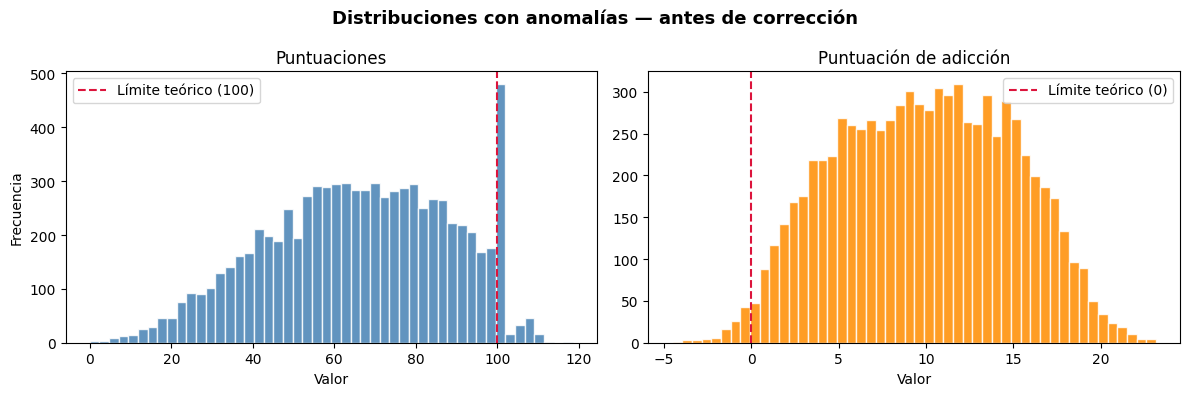

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribuciones con anomalías — antes de corrección', fontsize=13, fontweight='bold')

# Puntuaciones.
axes[0].hist(df['grades'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(100, color='crimson', linestyle='--', linewidth=1.5, label='Límite teórico (100)')
axes[0].set_title('Puntuaciones')
axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Adicción.
axes[1].hist(df['addiction_score'], bins=50, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='crimson', linestyle='--', linewidth=1.5, label='Límite teórico (0)')
axes[1].set_title('Puntuación de adicción')
axes[1].set_xlabel('Valor')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_anomalias_previas.png', dpi=120, bbox_inches='tight')
plt.show()

Podemos comprobar visualmente que son anomalías propias de los extremos, que serán corregidas a continuación.

## Correcciones y transformaciones

Aplicamos los cambios de forma explícita, mostrando qué se hizo y por qué.

In [18]:
# Quitamos los valores superiores a 100 en puntuaciones.
n_antes = (df['grades'] > 100).sum()
df['grades'] = df['grades'].clip(upper=100) # Se utiliza clip porque aplica un techo sin eliminar filas, ya que es importante mantener el resto de la información.
n_despues = (df['grades'] > 100).sum()

print(f'Registros con grades > 100  ->  antes: {n_antes} | después: {n_despues} ')
print(f'Nuevo rango: {df["grades"].min():.2f} – {df["grades"].max():.2f}')

Registros con grades > 100  ->  antes: 134 | después: 0 
Nuevo rango: 0.00 – 100.00


In [19]:
# Quitamos los valores inferiores a 0 en addiction_score.
n_antes = (df['addiction_score'] < 0).sum()
df['addiction_score'] = df['addiction_score'].clip(lower=0)
n_despues = (df['addiction_score'] < 0).sum()
print(f'Registros con addiction_score < 0  ->  antes: {n_antes} | después: {n_despues} ')
print(f'Nuevo rango: {df["addiction_score"].min():.2f} – {df["addiction_score"].max():.2f}')

Registros con addiction_score < 0  ->  antes: 107 | después: 0 
Nuevo rango: 0.00 – 23.16


In [ ]:
# Correción de los tipos.

# Categorias nominales, sin orden.
df['gender'] = df['gender'].astype('category')
df['gaming_genre'] = df['gaming_genre'].astype('category')

# Categoria ordinal praa que el modelo pueda interpretar el orden de estrés.
stress_order = pd.CategoricalDtype(categories=['Low', 'Medium', 'High'], ordered=True)
df['stress_level'] = df['stress_level'].astype(stress_order)

print('Tipos actualizados:')
print(df[['gender', 'gaming_genre', 'stress_level']].dtypes)


Tipos actualizados:
gender          category
gaming_genre    category
stress_level    category
dtype: object


También le damos a la ingeniería de variables para el modelo de ML posterior.

- Risk Flag: Esta variable será el target de clasificación en el notebook de modelado.

- Gaming Intensity: Segmenta las horas de gaming en categorías interpretables para el análisis y dashboard de Power BI.

In [21]:
# Risk flag.
UMBRAL_RIESGO = 50

df['risk_flag'] = (df['grades'] < UMBRAL_RIESGO).astype(int)

dist = df['risk_flag'].value_counts()
print(f'En riesgo (grades < {UMBRAL_RIESGO}) : {dist[1]:,} estudiantes ({dist[1]/len(df)*100:.1f}%)')
print(f'Sin riesgo                  : {dist[0]:,} estudiantes ({dist[0]/len(df)*100:.1f}%)')

En riesgo (grades < 50) : 2,011 estudiantes (25.1%)
Sin riesgo                  : 5,989 estudiantes (74.9%)


In [22]:
# Gaming intensity.
df['gaming_intensity'] = pd.cut(df['gaming_hours'], bins=[-0.01, 1, 3, 6, 8], labels=['Minimo (0-1h)','Moderado (1-3h)', 'Intenso (3-6h)','Extremo (6-8h)'])
print(df['gaming_intensity'].value_counts().sort_index())

gaming_intensity
Minimo (0-1h)       984
Moderado (1-3h)    1890
Intenso (3-6h)     3067
Extremo (6-8h)     2059
Name: count, dtype: int64


Parece que hay un poco de desbalance entre las variables de riesgo. Por otro lado, está más o menos balanceado las categorías de gaming_intensity.

## Verificación final

Confirmamos que el dataset resultante es exactamente lo que queremos.

In [23]:
# Resumen general.

print(f'--- RESUMENG GENERAL ---')
print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
print()
print(f'Tipos de datos:')
print(df.dtypes)

--- RESUMENG GENERAL ---
Filas: 8000 | Columnas: 16

Tipos de datos:
student_id             int64
age                    int64
gender              category
gaming_hours         float64
study_hours          float64
sleep_hours          float64
attendance           float64
gaming_genre        category
social_activity      float64
device_usage         float64
reaction_time_ms     float64
addiction_score      float64
stress_level        category
grades               float64
risk_flag              int64
gaming_intensity    category
dtype: object


In [24]:
# Confirmación de ausencia de nulos.
nulos_final = df.isnull().sum().sum()
if nulos_final == 0:
    print('No se encontraron valores nulos en el dataset final.')
else:
    print(f'Atención: Se encontraron {nulos_final} valores nulos en el dataset final.')

No se encontraron valores nulos en el dataset final.


In [25]:
# Confirmación de rangos corregidos.
checks = {
    'grades max <= 100'        : df['grades'].max() <= 100,
    'addiction_score min >= 0' : df['addiction_score'].min() >= 0,
    'risk_flag solo 0 y 1'     : set(df['risk_flag'].unique()) == {0, 1},
    'stress_level es ordinal'  : df['stress_level'].dtype.ordered,
}

for descripcion, resultado in checks.items():
    estado = 'OK' if resultado else 'Revisar'
    print(f'{estado}  {descripcion}')

OK  grades max <= 100
OK  addiction_score min >= 0
OK  risk_flag solo 0 y 1
OK  stress_level es ordinal


In [27]:
# Vista previa.
df.head(10)

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades,risk_flag,gaming_intensity
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.46,0,Extremo (6-8h)
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.23,0,Minimo (0-1h)
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.56,0,Moderado (1-3h)
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.67,1,Extremo (6-8h)
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.71,0,Intenso (3-6h)
5,6,18,Male,7.16,6.84,8.03,68.11,RPG,3.74,10.90,242.75,18.75,Low,57.52,0,Extremo (6-8h)
6,7,22,Female,0.46,7.40,6.55,91.25,Casual,1.81,2.86,320.20,1.74,Medium,94.00,0,Minimo (0-1h)
7,8,23,Female,4.78,6.79,5.37,66.46,FPS,2.85,9.96,271.21,11.75,Medium,62.11,0,Intenso (3-6h)
8,9,20,Female,4.55,7.93,8.76,72.50,FPS,1.00,9.48,272.39,11.04,Medium,80.94,0,Intenso (3-6h)
9,10,19,Male,0.29,4.24,7.83,71.39,Casual,3.07,5.39,318.59,4.72,Medium,82.35,0,Minimo (0-1h)


## Exportación


In [28]:
output_path = './data/GAP_clean.csv'
df.to_csv(output_path, index=False)
print(f'Dataset limpio exportado a: {output_path}')


Dataset limpio exportado a: ./data/GAP_clean.csv


## Tabla resumen de decisiones

In [29]:
decisiones = {
    'Columna'   : ['grades', 'addiction_score', 'gender / gaming_genre', 
                   'stress_level', '— (nueva)', '— (nueva)'],
    'Problema'  : ['Valores > 100', 'Valores negativos', 'Tipo object', 
                   'Tipo object sin orden', 'Target ML necesario', 
                   'Segmentación interpretable'],
    'Acción'    : ['clip(upper=100)', 'clip(lower=0)', 'Convertido a category', 
                   'CategoricalDtype ordenado', 'Creado risk_flag (grades < 50)', 
                   'Creado gaming_intensity (pd.cut)'],
    'Criterio'  : ['Nota máxima teórica = 100', 'Score de adicción no puede ser negativo',
                   'Eficiencia de memoria y agrupación', 'Low < Medium < High',
                   'Umbral de suspenso estándar', 'Útil para EDA y Power BI'],
}

pd.DataFrame(decisiones)

,Columna,Problema,Acción,Criterio
0,grades,Valores > 100,clip(upper=100),Nota máxima teórica = 100
1,addiction_score,Valores negativos,clip(lower=0),Score de adicción no puede ser negativo
2,gender / gaming_genre,Tipo object,Convertido a category,Eficiencia de memoria y agrupación
3,stress_level,Tipo object sin orden,CategoricalDtype ordenado,Low < Medium < High
4,— (nueva),Target ML necesario,Creado risk_flag (grades < 50),Umbral de suspenso estándar
5,— (nueva),Segmentación interpretable,Creado gaming_intensity (pd.cut),Útil para EDA y Power BI


Notebook completado! 

El dataset limpio ha sido exportado como 'GAP_clean.csv'.
Siguiente paso: EDA.